In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============== STEP 1: Simulate OT sensor data with a security scenario ==============

# Time vector
t = np.arange(0, 100, 0.5)  # 0 to 99.5 s, step 0.5 s
n = len(t)

# --- Normal behavior (0–60 s) ---
# Base signals with some dynamics and noise
current = (
    10
    + 2 * np.sin(2 * np.pi * 0.1 * t)
    + np.random.normal(0, 0.5, size=n)
)

temperature = (
    25
    + 5 * np.sin(2 * np.pi * 0.05 * t)
    + np.random.normal(0, 1, size=n)
)

vibration = (
    0.5
    + 0.2 * np.sin(2 * np.pi * 0.2 * t)
    + np.random.normal(0, 0.1, size=n)
)

# --- Security scenario: suspicious baseline shift at t >= 60 ---
# Imagine someone changed a setpoint or logic, shifting current upwards.
shift_time = 60
shift_magnitude = 3.0  # A

current[t >= shift_time] += shift_magnitude

# Optional: also make temperature drift a bit to look more realistic
temperature[t >= shift_time] += 2.0

In [3]:
# ============== STEP 2: Threshold-based alarms (operational) ==============

# Define thresholds (engineering limits)
current_threshold = 13
temp_threshold = 28
vib_threshold = 0.7

# Boolean alarms
current_alarm = current > current_threshold
temp_alarm = temperature > temp_threshold
vib_alarm = vibration > vib_threshold

In [4]:
# ============== STEP 3: Anomaly detection (security-relevant) ==============

# Use first 60 seconds as "normal" baseline
mask_normal = t < shift_time

# Compute normal statistics for current
mu_current_normal = np.mean(current[mask_normal])
sigma_current_normal = np.std(current[mask_normal])

# Anomaly if deviation from normal mean > k * sigma
k = 3
current_anomaly = np.abs(current - mu_current_normal) > k * sigma_current_normal

# (Optional) same idea for temperature
mu_temp_normal = np.mean(temperature[mask_normal])
sigma_temp_normal = np.std(temperature[mask_normal])
temp_anomaly = np.abs(temperature - mu_temp_normal) > k * sigma_temp_normal

In [5]:
# ============== STEP 4: Helper functions for reports ==============

def alarm_stats(alarm, time, name):
    """Return a short text summary for one alarm type."""
    num = np.sum(alarm)
    first_t = time[alarm][0] if np.any(alarm) else None
    if first_t is not None:
        return f"{name}: {num} alarm samples, first at t = {first_t:.1f} s"
    else:
        return f"{name}: no alarms"


def generate_shift_report_with_security(
    time,
    current,
    temperature,
    vibration,
    current_alarm,
    temp_alarm,
    vib_alarm,
    current_anomaly,
    temp_anomaly,
    shift_time,
    mu_current_normal,
    mu_temp_normal,
):
    """
    Generate a shift report that includes:
    - Signal statistics
    - Alarm summary
    - Security-relevant observations (baseline shifts, anomalies)
    """

    # 1. Signal statistics
    def signal_stats(data, name):
        mean_val = np.mean(data)
        max_val = np.max(data)
        std_val = np.std(data)
        return f"{name}: mean = {mean_val:.2f}, max = {max_val:.2f}, std = {std_val:.2f}"

    # 2. Alarm summary
    current_alarm_text = alarm_stats(current_alarm, time, "Current")
    temp_alarm_text = alarm_stats(temp_alarm, time, "Temperature")
    vib_alarm_text = alarm_stats(vib_alarm, time, "Vibration")

    # 3. Anomaly counts
    current_anomaly_count = np.sum(current_anomaly)
    temp_anomaly_count = np.sum(temp_anomaly)

    # 4. Simple security observations
    # Detect if mean changed significantly after shift_time
    mask_after = time >= shift_time
    mu_current_after = np.mean(current[mask_after])
    mu_temp_after = np.mean(temperature[mask_after])

    delta_current = mu_current_after - mu_current_normal
    delta_temp = mu_temp_after - mu_temp_normal

    # Build report
    lines = []
    lines.append("=" * 60)
    lines.append(f"Shift Report ({time[0]:.1f}–{time[-1]:.1f} s)")
    lines.append("=" * 60)

    lines.append("\nSignal Statistics:")
    lines.append(signal_stats(current, "Current (A)"))
    lines.append(signal_stats(temperature, "Temperature (C)"))
    lines.append(signal_stats(vibration, "Vibration (g)"))

    lines.append("\nAlarm Summary:")
    lines.append(current_alarm_text)
    lines.append(temp_alarm_text)
    lines.append(vib_alarm_text)

    lines.append("\nAnomaly Summary (statistical vs. normal baseline):")
    lines.append(f"Current anomalies: {current_anomaly_count} samples")
    lines.append(f"Temperature anomalies: {temp_anomaly_count} samples")

    lines.append("\nSecurity-Relevant Observations:")
    lines.append(f"- Baseline shift configured at t = {shift_time:.1f} s (simulated setpoint/logic change).")
    lines.append(f"- Current mean before shift: {mu_current_normal:.2f} A")
    lines.append(f"- Current mean after shift:  {mu_current_after:.2f} A (Δ = {delta_current:+.2f} A)")
    lines.append(f"- Temperature mean before shift: {mu_temp_normal:.2f} C")
    lines.append(f"- Temperature mean after shift:  {mu_temp_after:.2f} C (Δ = {delta_temp:+.2f} C)")
    lines.append("- Such shifts could indicate:")
    lines.append("  * Setpoint change or logic modification in PLC/SCADA")
    lines.append("  * Sensor drift or calibration issue")
    lines.append("  * Potential cyber incident affecting control parameters")
    lines.append("- Recommendation: check change logs, operator actions, and access records around t = {:.1f} s.".format(shift_time))

    lines.append("\nConclusion:")
    if current_anomaly_count > 0 or temp_anomaly_count > 0:
        lines.append("- Statistical anomalies detected; behavior after t = {:.1f} s differs from initial baseline.".format(shift_time))
        lines.append("- Correlate with operational events and security logs to determine root cause.")
    else:
        lines.append("- No significant statistical anomalies detected relative to the defined normal baseline.")

    lines.append("=" * 60)

    return "\n".join(lines)

In [6]:
# ============== STEP 5: Generate shift report with security notes ==============

report_text = generate_shift_report_with_security(
    t,
    current,
    temperature,
    vibration,
    current_alarm,
    temp_alarm,
    vib_alarm,
    current_anomaly,
    temp_anomaly,
    shift_time,
    mu_current_normal,
    mu_temp_normal,
)

print(report_text)

Shift Report (0.0–99.5 s)

Signal Statistics:
Current (A): mean = 11.21, max = 15.64, std = 2.13
Temperature (C): mean = 25.74, max = 33.28, std = 3.94
Vibration (g): mean = 0.49, max = 0.88, std = 0.17

Alarm Summary:
Current: 41 alarm samples, first at t = 60.5 s
Temperature: 73 alarm samples, first at t = 1.5 s
Vibration: 25 alarm samples, first at t = 0.0 s

Anomaly Summary (statistical vs. normal baseline):
Current anomalies: 18 samples
Temperature anomalies: 0 samples

Security-Relevant Observations:
- Baseline shift configured at t = 60.0 s (simulated setpoint/logic change).
- Current mean before shift: 9.98 A
- Current mean after shift:  13.04 A (Δ = +3.05 A)
- Temperature mean before shift: 24.95 C
- Temperature mean after shift:  26.93 C (Δ = +1.98 C)
- Such shifts could indicate:
  * Setpoint change or logic modification in PLC/SCADA
  * Sensor drift or calibration issue
  * Potential cyber incident affecting control parameters
- Recommendation: check change logs, operator a

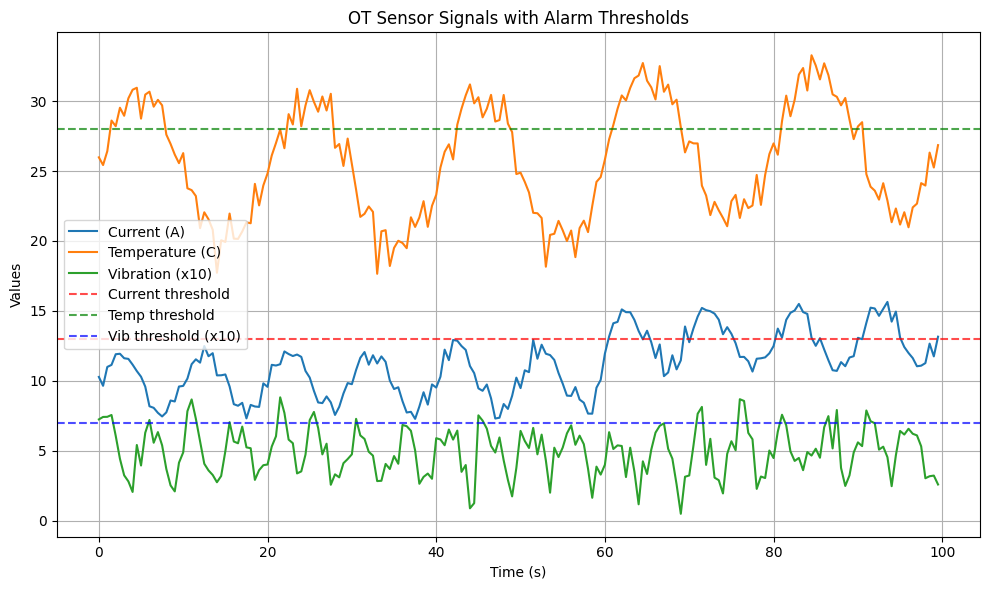

In [7]:
# ============== STEP 6: Plot 1 – Sensor data with thresholds ==============

plt.figure(figsize=(10, 6))

plt.plot(t, current, label="Current (A)")
plt.plot(t, temperature, label="Temperature (C)")
plt.plot(t, vibration * 10, label="Vibration (x10)")  # scaled for visibility

# Threshold lines
plt.axhline(current_threshold, color="r", linestyle="--", alpha=0.7, label="Current threshold")
plt.axhline(temp_threshold, color="g", linestyle="--", alpha=0.7, label="Temp threshold")
plt.axhline(vib_threshold * 10, color="b", linestyle="--", alpha=0.7, label="Vib threshold (x10)")

plt.xlabel("Time (s)")
plt.ylabel("Values")
plt.title("OT Sensor Signals with Alarm Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

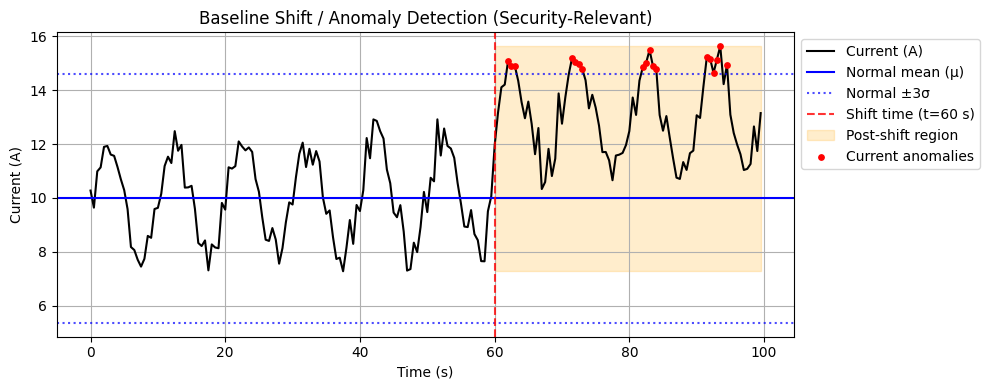

In [8]:
# ============== STEP 7: Plot 2 – Anomaly detection (baseline shift) ==============

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Plot current signal
ax.plot(t, current, label="Current (A)", color="black")

# Normal mean and ±3σ bands
ax.axhline(mu_current_normal, color="blue", linestyle="-", label="Normal mean (μ)")
ax.axhline(mu_current_normal + k * sigma_current_normal, color="blue", linestyle=":", alpha=0.7, label="Normal ±3σ")
ax.axhline(mu_current_normal - k * sigma_current_normal, color="blue", linestyle=":", alpha=0.7)

# Highlight anomaly region (t >= shift_time)
ax.axvline(shift_time, color="red", linestyle="--", alpha=0.8, label="Shift time (t=60 s)")
ax.fill_between(t, current.min(), current.max(),
                where=(t >= shift_time),
                color="orange", alpha=0.2, label="Post-shift region")

# Mark anomaly points
ax.scatter(t[current_anomaly], current[current_anomaly],
           color="red", s=15, zorder=3, label="Current anomalies")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax.set_title("Baseline Shift / Anomaly Detection (Security-Relevant)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(True)
plt.tight_layout()
plt.show()